nous allons appeller les elements deja calcule et stoque dans MACD elements
ou nous avons deja appliquer cela : 
{Prix→EWMA→MACD→normalisation→trend score}
et maintenant une fois appellée on applique : 
Xt​=31​(S,L)∑​0.89Yt​(S,L)e−Yt​(S,L)2/4​
et ensuite 
wt(i)​=Nt​1​Xt(i)​σt(i)​0.15​

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Racine du projet = 1er dossier parent qui contient "data/"
PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "data").is_dir()
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

FEATURE_FILE = PROCESSED_DIR / "classical_macd_features.csv"

assert FEATURE_FILE.exists(), f"Introuvable : {FEATURE_FILE}"
print("OK :", FEATURE_FILE)

OK : c:\Users\SETUP GAME\OneDrive\Desktop\Sun_project\Time_series_momentum\data\processed\classical_macd_features.csv


In [24]:
strategy_data = pd.read_csv(FEATURE_FILE, parse_dates=["date"])


In [25]:
STRATEGY_COLUMNS = [
    "daily_return",
    "volatility_60",
    "trend_score_8_24",
    "trend_score_16_48",
    "trend_score_32_96",
]

strategy_data = (
    strategy_data
    .dropna(subset=STRATEGY_COLUMNS)
    .sort_values(["date", "ticker"])
    .reset_index(drop=True)
)

print("Strategy-ready dataset:", strategy_data.shape)

display(
    strategy_data[
        [
            "date",
            "ticker",
            *STRATEGY_COLUMNS,
        ]
    ].head(20)
)

Strategy-ready dataset: (209580, 20)


,date,ticker,daily_return,volatility_60,trend_score_8_24,trend_score_16_48,trend_score_32_96
0,1981-05-15,BA,0.023166,0.295586,-2.216649,-2.684895,-2.574580
1,1981-05-15,BAC,-0.008266,0.248044,-0.196035,1.031123,1.653529
2,1981-05-15,CAT,-0.003572,0.226673,1.361574,2.158168,1.861569
3,1981-05-15,CVX,0.012580,0.350351,-0.255012,-1.111408,-0.441496
4,1981-05-15,GE,0.011741,0.204166,-0.955768,2.010544,3.423315
5,1981-05-15,JNJ,0.014069,0.205802,1.218222,3.535785,3.753392
6,1981-05-15,KO,0.007194,0.237008,-0.447834,0.643022,2.062494
7,1981-05-15,MCD,0.022588,0.234060,0.199376,1.918390,3.260249
8,1981-05-15,PFE,-0.009732,0.253553,0.108350,4.321476,4.787544
9,1981-05-15,PG,-0.001788,0.202480,0.125533,0.654554,0.444572


calcule de position sizing base sur le trend score avec la fonction  ϕ(y)=0.89yexp(−y2/4)​ 
Cette fonction est maximale autour de :

|y|= sqrt{2} approximativement 1.414

Au-delà, elle réduit progressivement l’exposition.

In [28]:
def position_sizing_function(
    trend_score: pd.Series,
) -> pd.Series:
    """
    Transform a standardized trend score into a position.

    Positive score -> long position
    Negative score -> short position
    Extreme score  -> reduced exposure
    """

    return (
        trend_score
        * np.exp(-(trend_score ** 2) / 4)
        / 0.89
    )

In [29]:
test_scores = pd.Series(
    [-4, -2, -np.sqrt(2), -1, 0, 1, np.sqrt(2), 2, 4],
    name="trend_score",
)

position_test = pd.DataFrame({
    "trend_score": test_scores,
    "position": position_sizing_function(test_scores),
})

display(position_test)

,trend_score,position
0,-4.000000,-0.082317
1,-2.000000,-0.826695
2,-1.414214,-0.963780
3,-1.000000,-0.875057
4,0.000000,0.000000
5,1.000000,0.875057
6,1.414214,0.963780
7,2.000000,0.826695
8,4.000000,0.082317


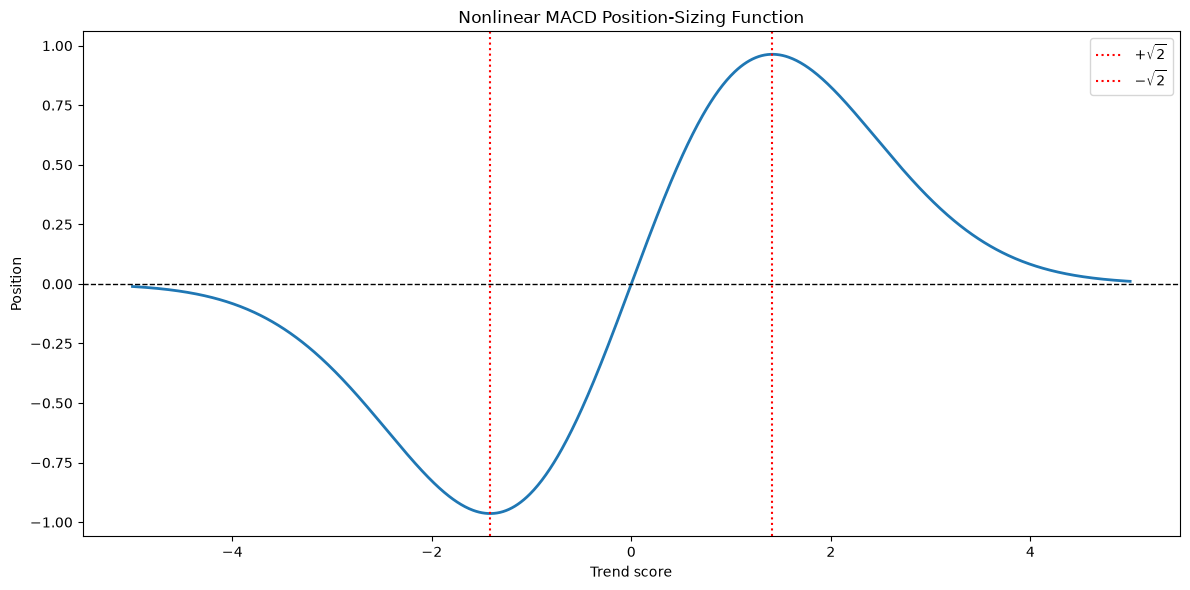

In [30]:
y_values = pd.Series(
    np.linspace(-5, 5, 1_000)
)

positions = position_sizing_function(y_values)

plt.figure(figsize=(12, 6))

plt.plot(
    y_values,
    positions,
    linewidth=2,
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

plt.axvline(
    np.sqrt(2),
    color="red",
    linestyle=":",
    label=r"$+\sqrt{2}$",
)

plt.axvline(
    -np.sqrt(2),
    color="red",
    linestyle=":",
    label=r"$-\sqrt{2}$",
)

plt.title("Nonlinear MACD Position-Sizing Function")
plt.xlabel("Trend score")
plt.ylabel("Position")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
strategy_data["position_8_24"] = (
    position_sizing_function(
        strategy_data["trend_score_8_24"]
    )
)

strategy_data["position_16_48"] = (
    position_sizing_function(
        strategy_data["trend_score_16_48"]
    )
)

strategy_data["position_32_96"] = (
    position_sizing_function(
        strategy_data["trend_score_32_96"]
    )
)

In [32]:
POSITION_COLUMNS = [
    "position_8_24",
    "position_16_48",
    "position_32_96",
]

strategy_data["macd_position"] = (
    strategy_data[POSITION_COLUMNS].mean(axis=1)
)

In [33]:
display_columns = [
    "date",
    "ticker",
    "trend_score_8_24",
    "position_8_24",
    "trend_score_16_48",
    "position_16_48",
    "trend_score_32_96",
    "position_32_96",
    "macd_position",
]

display(
    strategy_data[display_columns].head(20)
)

,date,ticker,trend_score_8_24,position_8_24,trend_score_16_48,position_16_48,trend_score_32_96,position_32_96,macd_position
0,1981-05-15,BA,-2.216649,-0.729167,-2.684895,-0.497584,-2.574580,-0.551621,-0.592791
1,1981-05-15,BAC,-0.196035,-0.218158,1.031123,0.888144,1.653529,0.937917,0.535968
2,1981-05-15,CAT,1.361574,0.962428,2.158168,0.756821,1.861569,0.879496,0.866248
3,1981-05-15,CVX,-0.255012,-0.281910,-1.111408,-0.917002,-0.441496,-0.472469,-0.557127
4,1981-05-15,GE,-0.955768,-0.854636,2.010544,0.822314,3.423315,0.205434,0.057704
5,1981-05-15,JNJ,1.218222,0.944509,3.535785,0.174475,3.753392,0.124582,0.414522
6,1981-05-15,KO,-0.447834,-0.478577,0.643022,0.651543,2.062494,0.800099,0.324355
7,1981-05-15,MCD,0.199376,0.221803,1.918390,0.858958,3.260249,0.256926,0.445896
8,1981-05-15,PFE,0.108350,0.121385,4.321476,0.045563,4.787544,0.017464,0.061471
9,1981-05-15,PG,0.125533,0.140493,0.654554,0.660752,0.444572,0.475437,0.425561


In [39]:
columns_to_validate = (
    POSITION_COLUMNS + ["macd_position"]
)

assert not strategy_data[
    columns_to_validate
].isna().any().any(), (
    "Some positions contain NaN values."
)

assert np.isfinite(
    strategy_data[columns_to_validate].to_numpy()
).all(), (
    "Some positions contain infinite values."
)

assert (
    strategy_data["macd_position"].abs() <= 1
).all(), (
    "Some final positions are outside the interval [-1, 1]."
)

print("All MACD positions were calculated successfully.")

All MACD positions were calculated successfully.


MACD position if positive we take long else negative we take short 

In [40]:
display(
    strategy_data[
        POSITION_COLUMNS + ["macd_position"]
    ].describe()
)

,position_8_24,position_16_48,position_32_96,macd_position
count,209580.000000,209580.000000,209580.000000,209580.000000
mean,0.219062,0.227151,0.264126,0.236779
std,0.732679,0.682146,0.606902,0.569914
min,-0.963780,-0.963780,-0.963780,-0.963683
25%,-0.579686,-0.401704,-0.069303,-0.205835
50%,0.540807,0.441141,0.395790,0.376511
75%,0.898557,0.863847,0.814865,0.729519
max,0.963780,0.963780,0.963780,0.963661


In [41]:
position_distribution = pd.Series({
    "long": (
        strategy_data["macd_position"] > 0
    ).mean(),

    "short": (
        strategy_data["macd_position"] < 0
    ).mean(),

    "exactly_zero": (
        strategy_data["macd_position"] == 0
    ).mean(),
})

display(
    position_distribution
    .mul(100)
    .rename("percentage")
)

long            68.630117
short           31.369883
exactly_zero     0.000000
Name: percentage, dtype: float64

prix historiques→trend scores→position MACD donc cette visualisation de test sur appl n'est pas un rendement cumule mais visualisation des positions long et short sur l'actif !

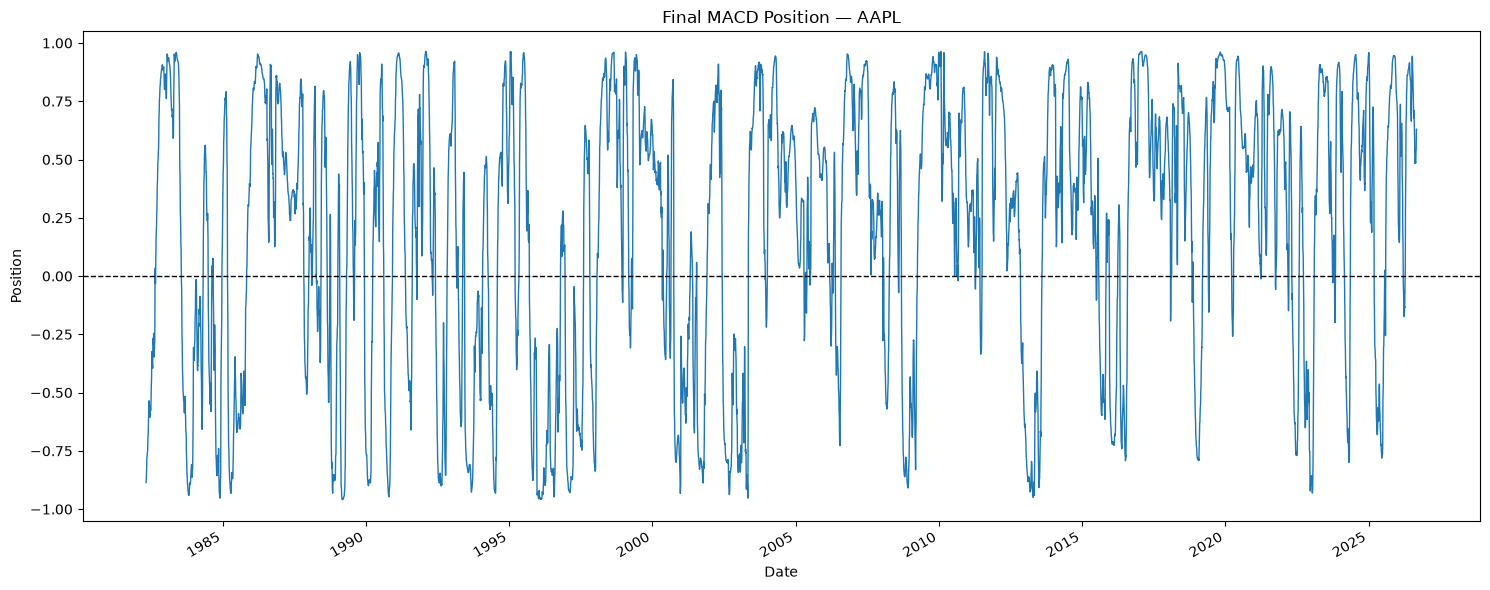

In [42]:
ticker_to_plot = "AAPL"

ticker_positions = (
    strategy_data[
        strategy_data["ticker"] == ticker_to_plot
    ]
    .set_index("date")
)

ticker_positions["macd_position"].plot(
    figsize=(15, 6),
    linewidth=1,
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

plt.title(f"Final MACD Position — {ticker_to_plot}")
plt.xlabel("Date")
plt.ylabel("Position")
plt.ylim(-1.05, 1.05)
plt.tight_layout()
plt.show()

## Maintenant la partie la plus important equilibre l'exposition avec la volatilite
en premier temps l'exposition ou position sizing etait definie que base sur la non linearite et le trend estimation variable maintenant on definie le holding potentiel base aussi sur volatilite 

In [43]:
TARGET_VOLATILITY=0.15 #15%
display(
    strategy_data["volatility_60"].describe()
)

count    209580.000000
mean          0.288186
std           0.137590
min           0.086192
25%           0.201654
50%           0.257379
75%           0.337088
max           1.764780
Name: volatility_60, dtype: float64

In [44]:
assert strategy_data["volatility_60"].notna().all(), (
    "Some volatility values are missing."
)

assert np.isfinite(
    strategy_data["volatility_60"]
).all(), (
    "Some volatility values are infinite."
)

assert (
    strategy_data["volatility_60"] > 0
).all(), (
    "Volatility must be strictly positive."
)

print("Volatility data successfully validated.")

Volatility data successfully validated.


In [45]:
strategy_data["volatility_multiplier"] = (
    TARGET_VOLATILITY
    / strategy_data["volatility_60"]
)

In [46]:
display(
    strategy_data[
        [
            "date",
            "ticker",
            "volatility_60",
            "volatility_multiplier",
        ]
    ].head(20)
)

,date,ticker,volatility_60,volatility_multiplier
0,1981-05-15,BA,0.295586,0.507466
1,1981-05-15,BAC,0.248044,0.604732
2,1981-05-15,CAT,0.226673,0.661746
3,1981-05-15,CVX,0.350351,0.428143
4,1981-05-15,GE,0.204166,0.734697
5,1981-05-15,JNJ,0.205802,0.728855
6,1981-05-15,KO,0.237008,0.632890
7,1981-05-15,MCD,0.234060,0.640860
8,1981-05-15,PFE,0.253553,0.591593
9,1981-05-15,PG,0.202480,0.740813


In [47]:
strategy_data["vol_scaled_position"] = (
    strategy_data["macd_position"]
    * strategy_data["volatility_multiplier"]
)

In [48]:
display_columns = [
    "date",
    "ticker",
    "macd_position",
    "volatility_60",
    "volatility_multiplier",
    "vol_scaled_position",
]

display(
    strategy_data[display_columns].head(20)
)

,date,ticker,macd_position,volatility_60,volatility_multiplier,vol_scaled_position
0,1981-05-15,BA,-0.592791,0.295586,0.507466,-0.300821
1,1981-05-15,BAC,0.535968,0.248044,0.604732,0.324117
2,1981-05-15,CAT,0.866248,0.226673,0.661746,0.573236
3,1981-05-15,CVX,-0.557127,0.350351,0.428143,-0.238530
4,1981-05-15,GE,0.057704,0.204166,0.734697,0.042395
5,1981-05-15,JNJ,0.414522,0.205802,0.728855,0.302126
6,1981-05-15,KO,0.324355,0.237008,0.632890,0.205281
7,1981-05-15,MCD,0.445896,0.234060,0.640860,0.285757
8,1981-05-15,PFE,0.061471,0.253553,0.591593,0.036366
9,1981-05-15,PG,0.425561,0.202480,0.740813,0.315261


In [49]:
assert strategy_data[
    "vol_scaled_position"
].notna().all(), (
    "Some volatility-scaled positions are missing."
)

assert np.isfinite(
    strategy_data["vol_scaled_position"]
).all(), (
    "Some volatility-scaled positions are infinite."
)

assert np.all(
    np.sign(strategy_data["vol_scaled_position"])
    ==
    np.sign(strategy_data["macd_position"])
), (
    "Volatility scaling unexpectedly changed position direction."
)

print("Volatility scaling successfully applied.")

Volatility scaling successfully applied.


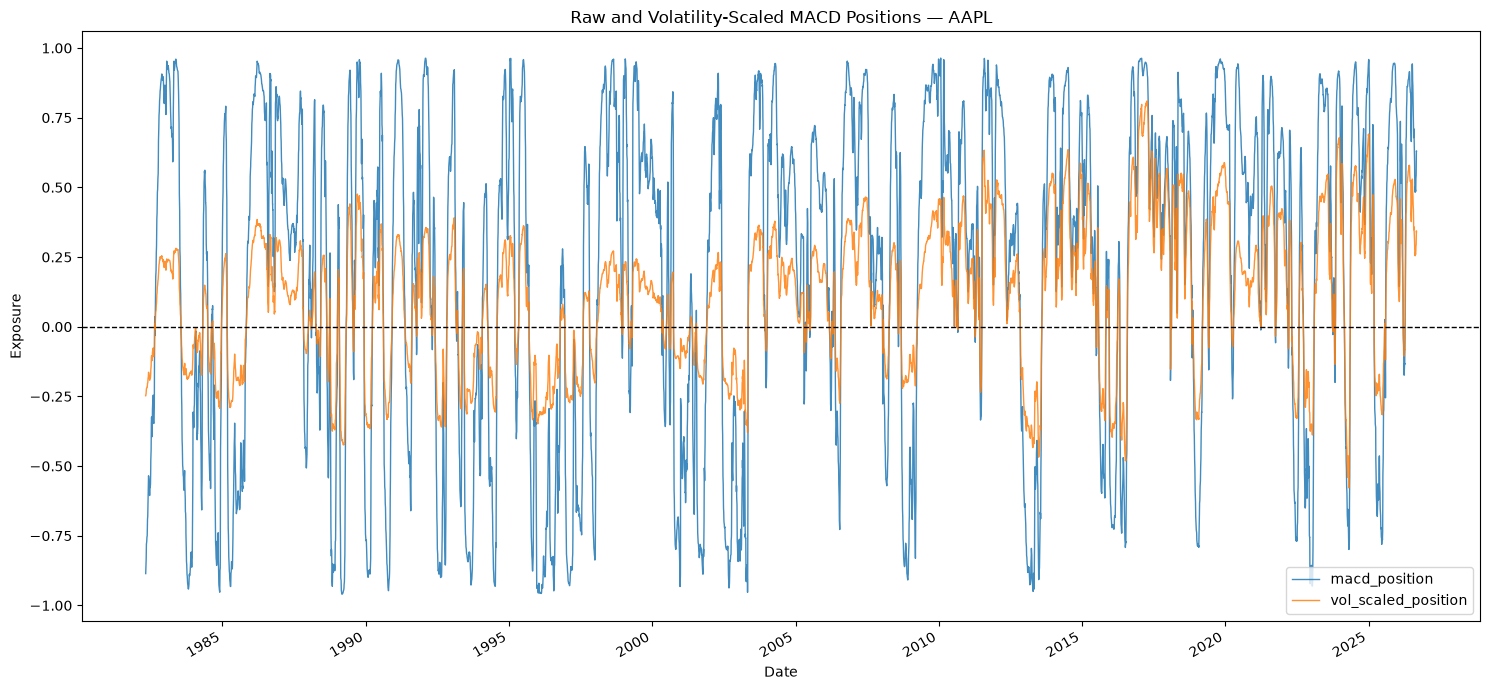

In [50]:
ticker_to_plot = "AAPL"

aapl_positions = (
    strategy_data[
        strategy_data["ticker"] == ticker_to_plot
    ]
    .set_index("date")
)

aapl_positions[
    [
        "macd_position",
        "vol_scaled_position",
    ]
].plot(
    figsize=(15, 7),
    linewidth=1,
    alpha=0.85,
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

plt.title(
    "Raw and Volatility-Scaled MACD Positions — AAPL"
)

plt.xlabel("Date")
plt.ylabel("Exposure")
plt.tight_layout()
plt.show()

In [51]:
display(
    strategy_data.loc[
        strategy_data["ticker"] == "AAPL",
        [
            "date",
            "macd_position",
            "volatility_60",
            "volatility_multiplier",
            "vol_scaled_position",
        ],
    ].tail(10)
)

,date,macd_position,volatility_60,volatility_multiplier,vol_scaled_position
209380,2026-08-24,0.489494,0.282191,0.531556,0.260193
209400,2026-08-25,0.485175,0.280599,0.534571,0.259360
209420,2026-08-26,0.493945,0.279534,0.536608,0.265055
209440,2026-08-27,0.504919,0.277953,0.539660,0.272484
209460,2026-08-28,0.532195,0.277523,0.540495,0.287649
209480,2026-08-31,0.543391,0.276483,0.542529,0.294806
209500,2026-09-01,0.579304,0.278096,0.539383,0.312467
209520,2026-09-02,0.604755,0.276517,0.542462,0.328056
209540,2026-09-03,0.630883,0.275296,0.544868,0.343748
209560,2026-09-04,0.629995,0.277454,0.540629,0.340594


In [52]:
direction_changes = (
    np.sign(strategy_data["macd_position"])
    !=
    np.sign(strategy_data["vol_scaled_position"])
).sum()

print("Unexpected direction changes:", direction_changes)

Unexpected direction changes: 0


exposition ajusteˊe→poids 1/Nt​→deˊcalage temporel→rendement quotidien du portefeuille→performance cumuleˊe

In [56]:
strategy_data["n_active_assets"] = (
    strategy_data
    .groupby("date")["ticker"]
    .transform("nunique")
)
display(
    strategy_data[
        ["date", "n_active_assets"]
    ]
    .drop_duplicates()
    .head(20)
)
display(
    strategy_data["n_active_assets"].describe()
)
strategy_data["portfolio_weight"] = (
    strategy_data["vol_scaled_position"]
    / strategy_data["n_active_assets"]
)

,date,n_active_assets
0,1981-05-15,12
12,1981-05-18,12
24,1981-05-19,12
36,1981-05-20,12
48,1981-05-21,12
60,1981-05-22,12
72,1981-05-26,12
84,1981-05-27,12
96,1981-05-28,12
108,1981-05-29,12


count    209580.000000
mean         18.545443
std           1.779641
min          12.000000
25%          17.000000
50%          19.000000
75%          20.000000
max          20.000000
Name: n_active_assets, dtype: float64

In [57]:
display(
    strategy_data[
        [
            "date",
            "ticker",
            "macd_position",
            "volatility_60",
            "volatility_multiplier",
            "vol_scaled_position",
            "n_active_assets",
            "portfolio_weight",
        ]
    ].head(20)
)

,date,ticker,macd_position,volatility_60,volatility_multiplier,vol_scaled_position,n_active_assets,portfolio_weight
0,1981-05-15,BA,-0.592791,0.295586,0.507466,-0.300821,12,-0.025068
1,1981-05-15,BAC,0.535968,0.248044,0.604732,0.324117,12,0.027010
2,1981-05-15,CAT,0.866248,0.226673,0.661746,0.573236,12,0.047770
3,1981-05-15,CVX,-0.557127,0.350351,0.428143,-0.238530,12,-0.019877
4,1981-05-15,GE,0.057704,0.204166,0.734697,0.042395,12,0.003533
5,1981-05-15,JNJ,0.414522,0.205802,0.728855,0.302126,12,0.025177
6,1981-05-15,KO,0.324355,0.237008,0.632890,0.205281,12,0.017107
7,1981-05-15,MCD,0.445896,0.234060,0.640860,0.285757,12,0.023813
8,1981-05-15,PFE,0.061471,0.253553,0.591593,0.036366,12,0.003030
9,1981-05-15,PG,0.425561,0.202480,0.740813,0.315261,12,0.026272


In [58]:
example = strategy_data.iloc[0]

expected_weight = (
    example["vol_scaled_position"]
    / example["n_active_assets"]
)

print("Calculated weight:", example["portfolio_weight"])
print("Expected weight  :", expected_weight)

Calculated weight: -0.025068408245653127
Expected weight  : -0.025068408245653127


In [59]:
assert strategy_data["n_active_assets"].notna().all()

assert (
    strategy_data["n_active_assets"] > 0
).all()

assert strategy_data[
    "portfolio_weight"
].notna().all()

assert np.isfinite(
    strategy_data["portfolio_weight"]
).all()

expected_weights = (
    strategy_data["vol_scaled_position"]
    / strategy_data["n_active_assets"]
)

assert np.allclose(
    strategy_data["portfolio_weight"],
    expected_weights,
)

print("Portfolio weights successfully calculated.")

Portfolio weights successfully calculated.


In [60]:
last_date = strategy_data["date"].max()

last_portfolio = (
    strategy_data[
        strategy_data["date"] == last_date
    ]
    [
        [
            "ticker",
            "macd_position",
            "volatility_60",
            "vol_scaled_position",
            "portfolio_weight",
        ]
    ]
    .sort_values(
        "portfolio_weight",
        ascending=False,
    )
)

print("Portfolio date:", last_date)
display(last_portfolio)

Portfolio date: 2026-09-04 00:00:00


,ticker,macd_position,volatility_60,vol_scaled_position,portfolio_weight
209570,JPM,0.925206,0.213058,0.651375,0.032569
209575,PFE,0.909432,0.219115,0.622571,0.031129
209563,BAC,0.802739,0.205448,0.586088,0.029304
209571,KO,0.737803,0.202661,0.546088,0.027304
209579,XOM,0.887819,0.267522,0.497802,0.024890
209565,CVX,0.766026,0.246485,0.466170,0.023309
209560,AAPL,0.629995,0.277454,0.340594,0.017030
209561,AMZN,0.786595,0.380633,0.309982,0.015499
209569,JNJ,0.443153,0.214770,0.309507,0.015475
209573,MSFT,0.573376,0.374878,0.229425,0.011471


In [61]:
portfolio_exposure = (
    strategy_data
    .groupby("date")
    .agg(
        n_active_assets=(
            "n_active_assets",
            "first",
        ),
        net_exposure=(
            "portfolio_weight",
            "sum",
        ),
        gross_exposure=(
            "portfolio_weight",
            lambda weights: weights.abs().sum(),
        ),
    )
)

display(portfolio_exposure.tail())

,n_active_assets,net_exposure,gross_exposure
date,,,
2026-08-31,20,0.164569,0.361273
2026-09-01,20,0.157057,0.359950
2026-09-02,20,0.153504,0.356949
2026-09-03,20,0.152449,0.356472
2026-09-04,20,0.151278,0.354978


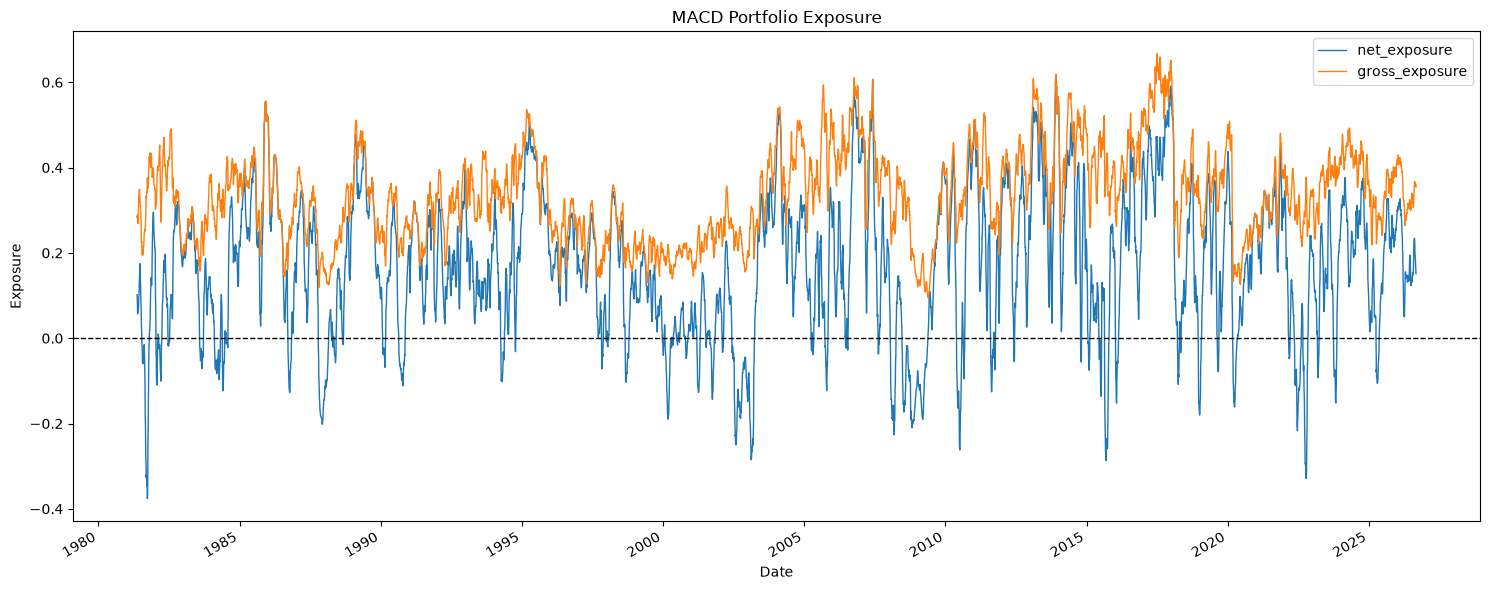

In [62]:
portfolio_exposure[
    ["net_exposure", "gross_exposure"]
].plot(
    figsize=(15, 6),
    linewidth=1,
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

plt.title("MACD Portfolio Exposure")
plt.xlabel("Date")
plt.ylabel("Exposure")
plt.tight_layout()
plt.show()

# BACKTEST 

In [63]:
strategy_data = (
    strategy_data
    .sort_values(["ticker", "date"])
    .reset_index(drop=True)
)

In [64]:
strategy_data["executed_weight"] = (
    strategy_data
    .groupby("ticker")["portfolio_weight"]
    .shift(1)
)

In [65]:
display(
    strategy_data.loc[
        strategy_data["ticker"] == "AAPL",
        [
            "date",
            "daily_return",
            "portfolio_weight",
            "executed_weight",
        ],
    ].head(10)
)

,date,daily_return,portfolio_weight,executed_weight
0,1982-04-28,-0.040981,-0.016520,NaN
1,1982-04-29,0.000000,-0.016483,-0.016520
2,1982-04-30,0.008546,-0.016294,-0.016483
3,1982-05-03,0.033897,-0.016011,-0.016294
4,1982-05-04,0.032800,-0.015693,-0.016011
5,1982-05-05,-0.015886,-0.015370,-0.015693
6,1982-05-06,0.032270,-0.015088,-0.015370
7,1982-05-07,0.015624,-0.014803,-0.015088
8,1982-05-10,-0.015384,-0.014774,-0.014803
9,1982-05-11,-0.031262,-0.014716,-0.014774


In [66]:
aapl_test = (
    strategy_data[
        strategy_data["ticker"] == "AAPL"
    ]
    .copy()
)

assert np.allclose(
    aapl_test["executed_weight"].iloc[1:],
    aapl_test["portfolio_weight"].iloc[:-1],
    equal_nan=True,
)

print("Temporal weight shift successfully validated.")

Temporal weight shift successfully validated.


In [67]:
strategy_data["asset_strategy_return"] = (
    strategy_data["executed_weight"]
    * strategy_data["daily_return"]
)

In [68]:
display(
    strategy_data.loc[
        strategy_data["ticker"] == "AAPL",
        [
            "date",
            "daily_return",
            "portfolio_weight",
            "executed_weight",
            "asset_strategy_return",
        ],
    ].head(10)
)

,date,daily_return,portfolio_weight,executed_weight,asset_strategy_return
0,1982-04-28,-0.040981,-0.016520,NaN,NaN
1,1982-04-29,0.000000,-0.016483,-0.016520,-0.000000
2,1982-04-30,0.008546,-0.016294,-0.016483,-0.000141
3,1982-05-03,0.033897,-0.016011,-0.016294,-0.000552
4,1982-05-04,0.032800,-0.015693,-0.016011,-0.000525
5,1982-05-05,-0.015886,-0.015370,-0.015693,0.000249
6,1982-05-06,0.032270,-0.015088,-0.015370,-0.000496
7,1982-05-07,0.015624,-0.014803,-0.015088,-0.000236
8,1982-05-10,-0.015384,-0.014774,-0.014803,0.000228
9,1982-05-11,-0.031262,-0.014716,-0.014774,0.000462


In [69]:
portfolio_daily_returns = (
    strategy_data
    .groupby("date")["asset_strategy_return"]
    .sum(min_count=1)
    .rename("portfolio_return")
    .dropna()
    .to_frame()
)

In [70]:
print("Backtest start:", portfolio_daily_returns.index.min())
print("Backtest end  :", portfolio_daily_returns.index.max())
print("Observations  :", len(portfolio_daily_returns))

display(portfolio_daily_returns.head())
display(portfolio_daily_returns.tail())

Backtest start: 1981-05-18 00:00:00
Backtest end  : 2026-09-04 00:00:00
Observations  : 11418


,portfolio_return
date,
1981-05-18,0.000854
1981-05-19,0.000974
1981-05-20,0.000802
1981-05-21,0.000225
1981-05-22,0.000811


,portfolio_return
date,
2026-08-31,-0.000404
2026-09-01,0.001136
2026-09-02,0.000750
2026-09-03,0.001074
2026-09-04,-0.001727


In [71]:
assert not portfolio_daily_returns.empty

assert portfolio_daily_returns.index.is_monotonic_increasing

assert not portfolio_daily_returns.index.duplicated().any()

assert portfolio_daily_returns[
    "portfolio_return"
].notna().all()

assert np.isfinite(
    portfolio_daily_returns["portfolio_return"]
).all()

print("Daily portfolio returns successfully calculated.")

Daily portfolio returns successfully calculated.


In [72]:
portfolio_daily_returns["wealth_index"] = (
    1
    + portfolio_daily_returns["portfolio_return"]
).cumprod()

In [73]:
portfolio_daily_returns["cumulative_return"] = (
    portfolio_daily_returns["wealth_index"] - 1
)

In [74]:
display(portfolio_daily_returns.tail())

,portfolio_return,wealth_index,cumulative_return
date,,,
2026-08-31,-0.000404,2.299085,1.299085
2026-09-01,0.001136,2.301696,1.301696
2026-09-02,0.000750,2.303423,1.303423
2026-09-03,0.001074,2.305897,1.305897
2026-09-04,-0.001727,2.301914,1.301914


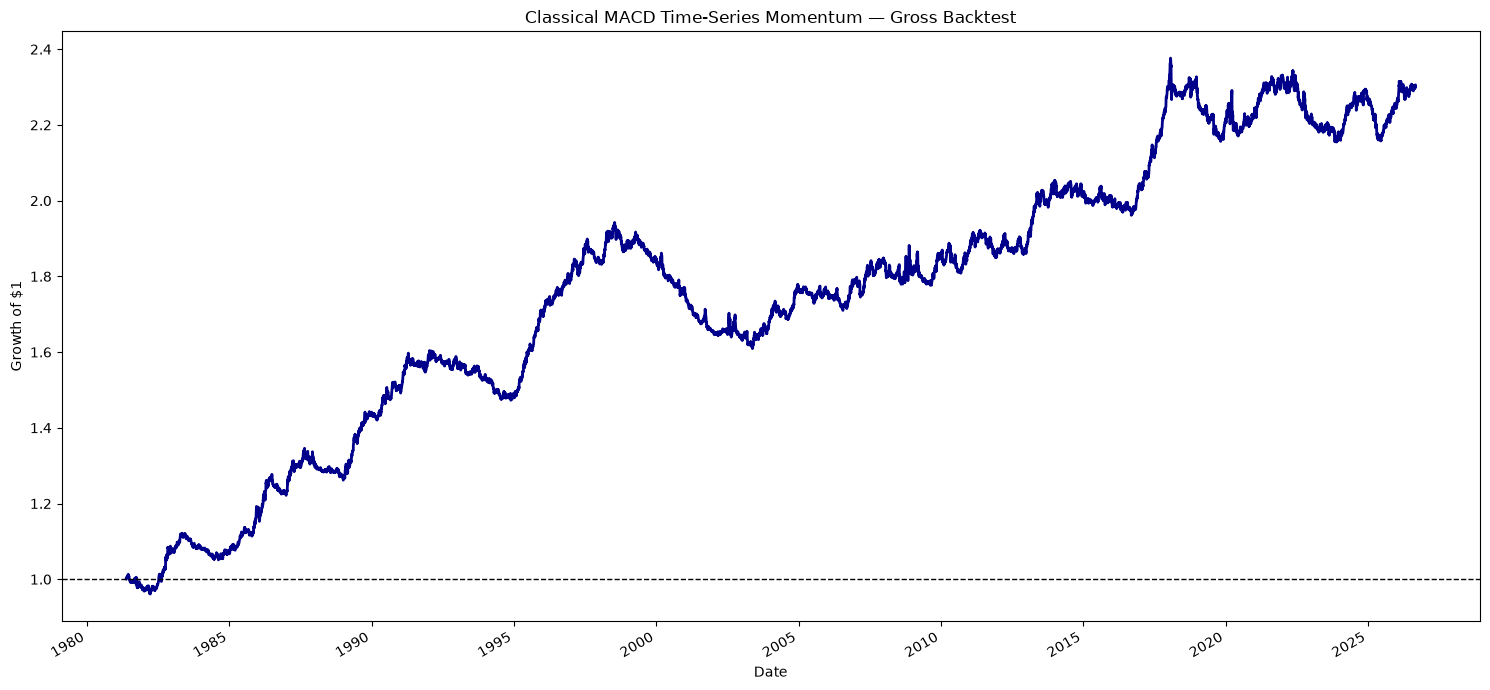

In [75]:
ax = portfolio_daily_returns[
    "wealth_index"
].plot(
    figsize=(15, 7),
    linewidth=2,
    color="darkblue",
)

ax.axhline(
    1,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.set_title(
    "Classical MACD Time-Series Momentum — Gross Backtest"
)

ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")

plt.tight_layout()
plt.show()

In [76]:
final_wealth = portfolio_daily_returns[
    "wealth_index"
].iloc[-1]

final_cumulative_return = portfolio_daily_returns[
    "cumulative_return"
].iloc[-1]

print(f"Final wealth            : {final_wealth:.4f}")
print(
    f"Final cumulative return : "
    f"{final_cumulative_return:.2%}"
)

Final wealth            : 2.3019
Final cumulative return : 130.19%


In [78]:
final_wealth = portfolio_daily_returns[
    "wealth_index"
].iloc[-1]

final_cumulative_return = portfolio_daily_returns[
    "cumulative_return"
].iloc[-1]

start_date = portfolio_daily_returns.index.min()
end_date = portfolio_daily_returns.index.max()

print("Start date              :", start_date)
print("End date                :", end_date)
print(f"Final wealth            : {final_wealth:.4f}")
print(f"Final cumulative return : {final_cumulative_return:.2%}")

Start date              : 1981-05-18 00:00:00
End date                : 2026-09-04 00:00:00
Final wealth            : 2.3019
Final cumulative return : 130.19%


In [79]:
display(
    portfolio_daily_returns[
        "portfolio_return"
    ].describe(
        percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
    )
)

print(
    "Minimum daily return:",
    portfolio_daily_returns["portfolio_return"].min()
)

print(
    "Maximum daily return:",
    portfolio_daily_returns["portfolio_return"].max()
)

count    11418.000000
mean         0.000076
std          0.002323
min         -0.028827
1%          -0.006322
5%          -0.003606
50%          0.000111
95%          0.003595
99%          0.006193
max          0.013685
Name: portfolio_return, dtype: float64

Minimum daily return: -0.02882666546999996
Maximum daily return: 0.013684834126502751


 METRIC finale du backtest qui seront compare avec LSTM :

In [80]:
def calculate_performance_metrics(
    portfolio_returns: pd.Series,
    strategy_name: str,
    periods_per_year: int = 252,
    risk_free_rate: float = 0.0,
) -> pd.DataFrame:
    """
    Calculate performance metrics from daily portfolio returns.

    Parameters
    ----------
    portfolio_returns:
        Daily returns of the portfolio.
    strategy_name:
        Name used in the comparison table.
    periods_per_year:
        Number of trading periods per year.
    risk_free_rate:
        Annual risk-free rate. Currently set to zero.
    """

    returns = (
        portfolio_returns
        .dropna()
        .astype(float)
    )

    if returns.empty:
        raise ValueError("The return series is empty.")

    if (returns <= -1).any():
        raise ValueError(
            "At least one return is less than or equal to -100%."
        )

    # -----------------------------------------------------
    # General information
    # -----------------------------------------------------

    observations = len(returns)

    start_date = returns.index.min()
    end_date = returns.index.max()

    number_of_years = (
        end_date - start_date
    ).days / 365.25

    # -----------------------------------------------------
    # Wealth and cumulative return
    # -----------------------------------------------------

    wealth_index = (1 + returns).cumprod()

    final_wealth = wealth_index.iloc[-1]

    cumulative_return = final_wealth - 1

    # -----------------------------------------------------
    # CAGR
    # -----------------------------------------------------

    if number_of_years > 0 and final_wealth > 0:
        cagr = (
            final_wealth ** (1 / number_of_years)
            - 1
        )
    else:
        cagr = np.nan

    # -----------------------------------------------------
    # Annualized volatility
    # -----------------------------------------------------

    annualized_volatility = (
        returns.std(ddof=1)
        * np.sqrt(periods_per_year)
    )

    # -----------------------------------------------------
    # Annualized Sharpe ratio
    # -----------------------------------------------------

    daily_risk_free_rate = (
        (1 + risk_free_rate)
        ** (1 / periods_per_year)
        - 1
    )

    excess_returns = (
        returns - daily_risk_free_rate
    )

    if excess_returns.std(ddof=1) > 0:
        sharpe_ratio = (
            excess_returns.mean()
            / excess_returns.std(ddof=1)
            * np.sqrt(periods_per_year)
        )
    else:
        sharpe_ratio = np.nan

    # -----------------------------------------------------
    # Sortino ratio
    # -----------------------------------------------------

    downside_returns = np.minimum(
        excess_returns,
        0,
    )

    downside_deviation = (
        np.sqrt(
            np.mean(downside_returns ** 2)
        )
        * np.sqrt(periods_per_year)
    )

    annualized_excess_return = (
        excess_returns.mean()
        * periods_per_year
    )

    if downside_deviation > 0:
        sortino_ratio = (
            annualized_excess_return
            / downside_deviation
        )
    else:
        sortino_ratio = np.nan

    # -----------------------------------------------------
    # Drawdown
    # -----------------------------------------------------

    running_max = wealth_index.cummax()

    drawdown = (
        wealth_index / running_max
        - 1
    )

    maximum_drawdown = drawdown.min()

    # -----------------------------------------------------
    # Calmar ratio
    # -----------------------------------------------------

    if maximum_drawdown < 0:
        calmar_ratio = (
            cagr / abs(maximum_drawdown)
        )
    else:
        calmar_ratio = np.nan

    # -----------------------------------------------------
    # Additional statistics
    # -----------------------------------------------------

    hit_rate = (returns > 0).mean()

    positive_returns = returns[
        returns > 0
    ]

    negative_returns = returns[
        returns < 0
    ]

    average_daily_return = returns.mean()

    best_day = returns.max()
    worst_day = returns.min()

    average_profit = (
        positive_returns.mean()
        if not positive_returns.empty
        else np.nan
    )

    average_loss = (
        negative_returns.mean()
        if not negative_returns.empty
        else np.nan
    )

    profit_loss_ratio = (
        average_profit / abs(average_loss)
        if (
            pd.notna(average_loss)
            and average_loss != 0
        )
        else np.nan
    )

    # -----------------------------------------------------
    # Result table
    # -----------------------------------------------------

    metrics = pd.DataFrame(
        {
            "strategy": [strategy_name],
            "start_date": [start_date],
            "end_date": [end_date],
            "observations": [observations],
            "years": [number_of_years],
            "final_wealth": [final_wealth],
            "cumulative_return": [cumulative_return],
            "cagr": [cagr],
            "annualized_volatility": [
                annualized_volatility
            ],
            "sharpe_ratio": [sharpe_ratio],
            "sortino_ratio": [sortino_ratio],
            "maximum_drawdown": [
                maximum_drawdown
            ],
            "calmar_ratio": [calmar_ratio],
            "hit_rate": [hit_rate],
            "average_daily_return": [
                average_daily_return
            ],
            "average_profit": [average_profit],
            "average_loss": [average_loss],
            "profit_loss_ratio": [
                profit_loss_ratio
            ],
            "best_day": [best_day],
            "worst_day": [worst_day],
        }
    ).set_index("strategy")

    return metrics

In [81]:
macd_metrics = calculate_performance_metrics(
    portfolio_returns=(
        portfolio_daily_returns["portfolio_return"]
    ),
    strategy_name="Classical MACD",
)

display(macd_metrics.T)

strategy,Classical MACD
start_date,1981-05-18 00:00:00
end_date,2026-09-04 00:00:00
observations,11418
years,45.297741
final_wealth,2.301914
cumulative_return,1.301914
cagr,0.018576
annualized_volatility,0.036877
sharpe_ratio,0.517456
sortino_ratio,0.72321


In [83]:
portfolio_daily_returns["running_max"] = (
    portfolio_daily_returns[
        "wealth_index"
    ].cummax()
)

portfolio_daily_returns["drawdown"] = (
    portfolio_daily_returns["wealth_index"]
    / portfolio_daily_returns["running_max"]
    - 1
)

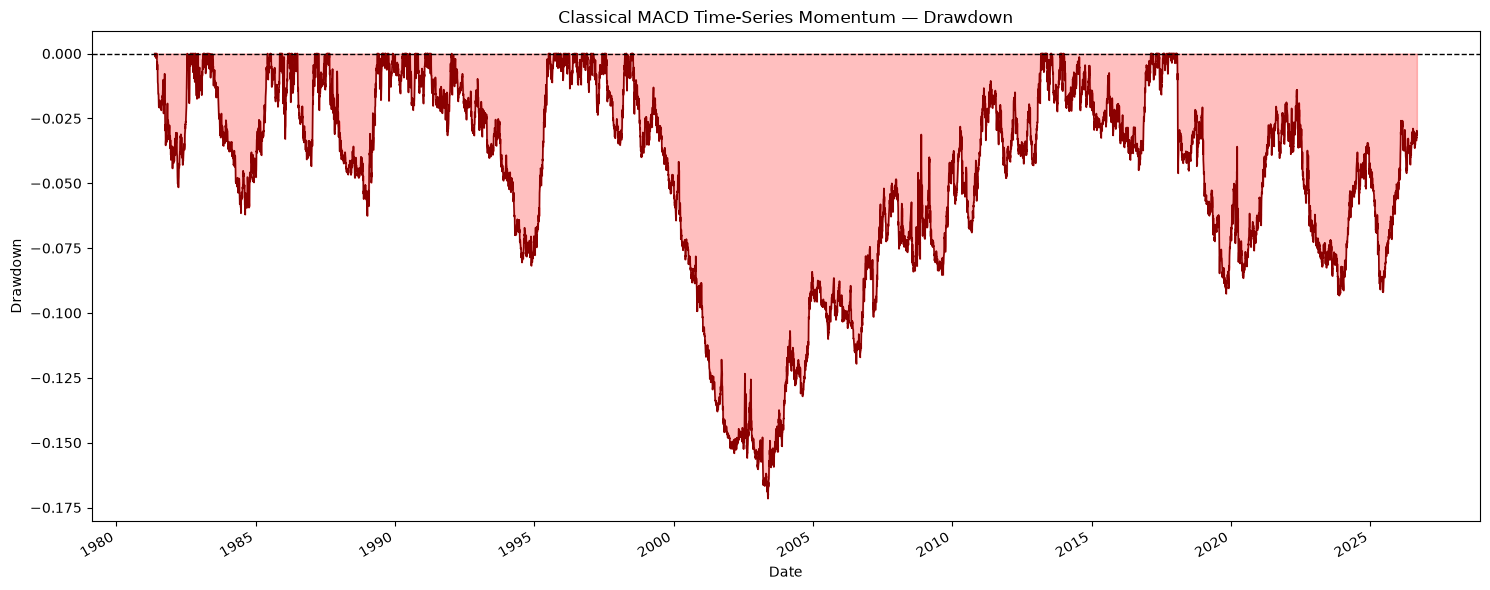

In [84]:
ax = portfolio_daily_returns[
    "drawdown"
].plot(
    figsize=(15, 6),
    color="darkred",
    linewidth=1.2,
)

ax.fill_between(
    portfolio_daily_returns.index,
    portfolio_daily_returns["drawdown"],
    0,
    color="red",
    alpha=0.25,
)

ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.set_title(
    "Classical MACD Time-Series Momentum — Drawdown"
)

ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")

plt.tight_layout()
plt.show()

In [85]:
#sauvgarder les resultats pour les comparer prochainement
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [86]:
METRICS_FILE = (
    RESULTS_DIR / "strategy_comparison_metrics.csv"
)

macd_metrics.to_csv(
    METRICS_FILE,
    index=True,
)

In [87]:
BACKTEST_FILE = (
    RESULTS_DIR
    / "classical_macd_daily_backtest.csv"
)

portfolio_daily_returns.to_csv(
    BACKTEST_FILE,
    index=True,
)